# Customer Churn Prediction using Machine Learning

## Project Overview
Customer churn is a major challenge for subscription-based businesses such as telecommunications companies. This project develops an interpretable machine learning model to predict customer churn and identify the key factors that drive customer attrition.

The objective is not only to build a predictive model, but also to translate model insights into actionable business strategies that can reduce churn and improve customer retention.



## Business Problem
Customer acquisition is significantly more expensive than customer retention. For telecom companies, the ability to identify customers at risk of leaving is critical for designing proactive retention strategies such as personalized offers, contract incentives, and targeted support.

By predicting churn in advance, companies can focus their resources on the customers most likely to leave and improve long-term customer lifetime value.



## Objective
The goal of this project is to build an interpretable machine learning model that predicts customer churn and uncovers the main drivers behind customer attrition.

### Project Goals
- Predict which customers are likely to churn
- Identify the most important drivers of churn
- Provide actionable business recommendations based on model insights



## Dataset
This project uses the **Telco Customer Churn dataset (IBM sample)**.

Dataset characteristics:
- Approximately 7,000 telecom customers
- Customer demographics and account information
- Services subscribed and contract type
- Billing and payment information
- Customer tenure and charges
- Target variable: **Churn**



## Success Criteria
The project will be considered successful if it:
- Builds a reliable and interpretable churn prediction model
- Identifies key factors influencing churn
- Produces business recommendations that can help reduce churn


## Table of Contents
1. Data Loading  
2. Exploratory Data Analysis  
3. Data Cleaning  
4. Feature Engineering  
5. Modeling  
6. Model Evaluation  
7. Model Interpretation  
8. Business Insights  
9. Conclusions  

## Imports

In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Load Dataset

We load the Telco Customer Churn dataset from a public GitHub repository and inspect its structure.

In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


The dataset contains customer demographics, subscribed services, billing information, and churn status.
The target variable is **Churn**.

## Initial Exploration

In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

Shape: (7043, 21)

Columns:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Check Target Variable

In [8]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


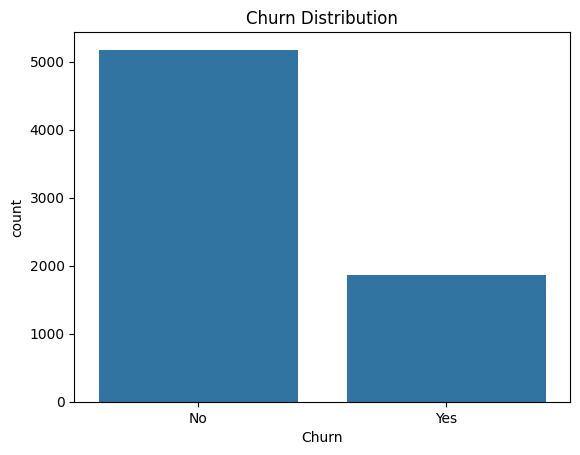

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

- The dataset is imbalanced: fewer customers churn than stay.
- This will impact model performance and must be handled carefully.

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()

np.int64(11)

In [11]:
df = df.dropna()

### Convert Target to Binary

In [12]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

- Churn has been converted to a binary variable (1 = churn, 0 = no churn)
- This allows us to use classification models

### Drop customer ID

In [13]:
df = df.drop('customerID', axis=1)

### Separate numeric and categoric

In [14]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(exclude='object').columns

print("Categorical:", list(cat_cols))
print("Numerical:", list(num_cols))

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']


## Binary Encoding of Yes/No Features


Many features are binary categorical variables (Yes/No or Male/Female).
Converting them to numeric format improves model compatibility and performance.



In [15]:
# Identify binary categorical columns BEFORE any transformation
binary_cols = [
    'gender','Partner','Dependents','PhoneService','PaperlessBilling'
]

# Map Male/Female first (different mapping)
df['gender'] = df['gender'].map({'Male':1, 'Female':0})

# Map Yes/No columns
yes_no_cols = ['Partner','Dependents','PhoneService','PaperlessBilling']

for col in yes_no_cols:
    df[col] = df[col].map({'Yes':1, 'No':0})

In [16]:
df[binary_cols].head()

,gender,Partner,Dependents,PhoneService,PaperlessBilling
0,0,1,0,0,1
1,1,0,0,1,0
2,1,0,0,1,1
3,1,0,0,0,0
4,0,0,0,1,1


In [17]:
df[binary_cols].isnull().sum()

,0
gender,0
Partner,0
Dependents,0
PhoneService,0
PaperlessBilling,0


Machine learning models require numerical input. Converting categorical variables into numeric format allows the model to learn relationships between customer characteristics and churn behavior.

Binary categorical variables have been converted to 0/1
Remaining categorical variables will be transformed using one-hot encoding in the next step
This prepares the dataset for advanced feature engineering and modeling.

In [18]:
df['gender'].isnull().sum()

np.int64(0)

### Data Cleaning Summary

- Removed customerID (non-informative identifier)
- Converted TotalCharges to numeric and removed missing values
- Converted target variable Churn to binary
- Converted binary categorical variables (Yes/No) to numeric format

The dataset is now ready for exploratory data analysis and feature engineering.

In [19]:
df.select_dtypes(include='object').columns

Index(['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaymentMethod'],
      dtype='object')

## Exploratory Data Analysis

### Churn Distribution

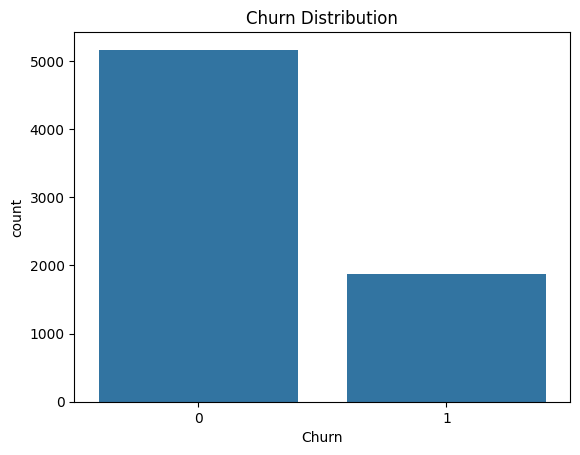

,proportion
Churn,
0,0.734215
1,0.265785


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

df['Churn'].value_counts(normalize=True)

About ~26% of customers churn, confirming a class imbalance problem.
This will influence model evaluation and metric selection.

### Churn vs Contract

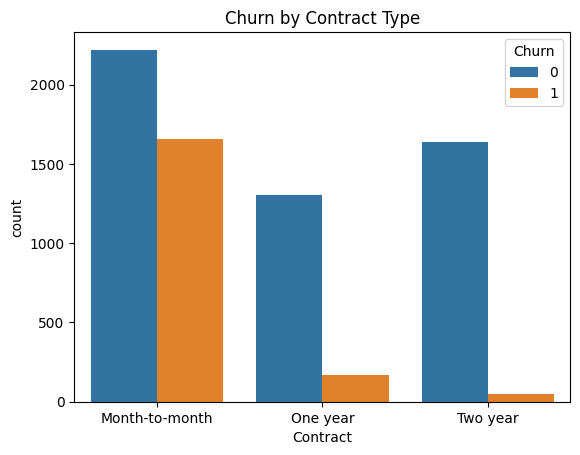

In [21]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.show()

Month-to-month customers show dramatically higher churn.
Long-term contracts strongly reduce churn risk.

### Churn vs Tenure

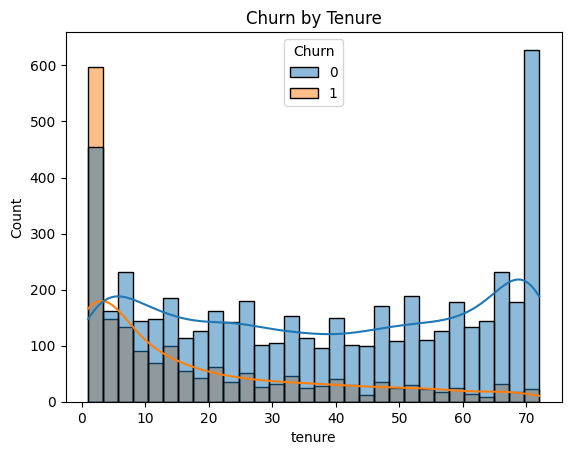

In [22]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title("Churn by Tenure")
plt.show()

New customers have the highest churn risk.
Churn probability decreases as tenure increases.

### Churn vs Monthly Charges

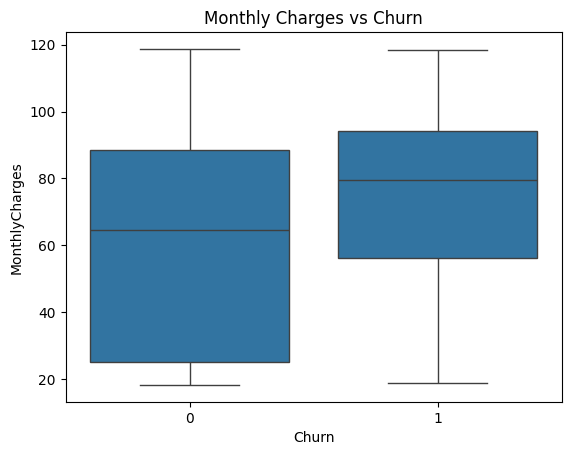

In [23]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

Customers paying higher monthly charges churn more frequently.

### Churn vs Internet Service

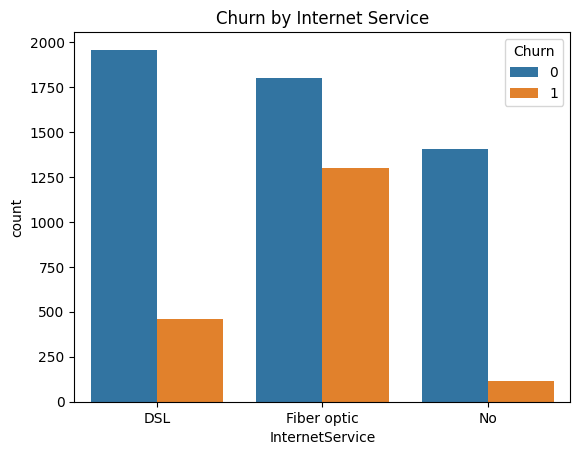

In [24]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Churn by Internet Service")
plt.show()

## Key Insights from EDA

• Month-to-month contracts are the highest-risk segment  
• New customers are significantly more likely to churn  
• Higher monthly charges correlate with churn  
• Certain service combinations show higher churn patterns  

These insights suggest that early-stage customers and flexible contracts are critical targets for retention strategies.

##Feature Engineering

Raw data rarely produces the best machine learning models.
Feature engineering transforms the dataset into a format that allows models to better capture patterns related to churn.
In this section we will:
Encode categorical variables
Create new meaningful features
Scale numerical variables
Prepare the final dataset for modeling
This shows business understanding + ML maturity.

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   int64  
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   int64  
 3   Dependents        7032 non-null   int64  
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   int64  
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   int64  
 16  PaymentMethod     7032 non-null   object 
 17  

## Tenure Groups

In [26]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,60,100],
    labels=['0-1yr','1-2yr','2-4yr','4-5yr','5+yr']
)

## Average Monthly Spend

In [27]:
df['avg_monthly_spend'] = df['TotalCharges'] / (df['tenure'] + 1)

## Number of Services

In [28]:
services = [
    'PhoneService','MultipleLines','InternetService','OnlineSecurity',
    'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]

df['num_services'] = (df[services] == 'Yes').sum(axis=1)

In [29]:
df[['tenure_group','avg_monthly_spend','num_services']].head()

,tenure_group,avg_monthly_spend,num_services
0,0-1yr,14.925000,1
1,2-4yr,53.985714,2
2,0-1yr,36.050000,2
3,2-4yr,40.016304,3
4,0-1yr,50.550000,0


Raw data rarely produces the best predictive performance.
We created new features that capture customer behavior more effectively.

New features created:

- Tenure groups
Customers were segmented into lifecycle stages to capture early-stage churn risk.
- Number of subscribed services
Customers with more services are typically more engaged and less likely to churn.
- Average monthly spend
TotalCharges / tenure provides a proxy for long-term customer value.

## One-Hot Encoding of Multi-Category Features

Some variables contain more than two categories (for example: Contract type or Payment Method).

These features cannot be represented using simple binary mapping.

We apply one-hot encoding to:

- Prevent the model from assuming ordinal relationships
- Allow each category to contribute independently to churn prediction


In [30]:
categorical_cols = [
    'MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
    'Contract','PaymentMethod','tenure_group'
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

## Feature Scaling

Logistic Regression performs best when numerical features are on a similar scale.

We apply StandardScaler to:

- Normalize numerical variables
- Improve model convergence
- Ensure coefficients are comparable

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = [
    'tenure','MonthlyCharges','TotalCharges',
    'avg_monthly_spend','num_services'
]

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [32]:
df.shape
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-2yr,tenure_group_2-4yr,tenure_group_4-5yr,tenure_group_5+yr
0,0,0,1,0,-1.280248,0,1,-1.161694,-0.994194,0,...,False,False,False,False,True,False,False,False,False,False
1,1,0,0,0,0.064303,1,0,-0.260878,-0.173740,0,...,False,True,False,False,False,True,False,True,False,False
2,1,0,0,0,-1.239504,1,1,-0.363923,-0.959649,1,...,False,False,False,False,False,True,False,False,False,False
3,1,0,0,0,0.512486,0,0,-0.747850,-0.195248,0,...,False,True,False,False,False,False,False,True,False,False
4,0,0,0,0,-1.239504,1,1,0.196178,-0.940457,1,...,False,False,False,False,True,False,False,False,False,False


## Modeling (Predicting Customer Churn)

Split the dataset into train/test sets
Train a baseline Logistic Regression model
Evaluate performance using proper churn metrics


## Define X and y

In [33]:
X = df.drop('Churn', axis=1)
y = df['Churn']

## Train-Test Split
To evaluate model performance on unseen data, the dataset is split into:
- Training set (80%) → used to train the model
- Test set (20%) → used to evaluate real-world performance

This prevents overfitting and ensures the model generalizes to new customers.

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (5625, 36)
Test size: (1407, 36)


## Logistic Regression

We start with Logistic Regression because:

- It is highly interpretable
- Coefficients directly show feature impact
- It is widely used as a baseline in churn prediction

Interpretability is critical because the goal is not only prediction, but also business decision support.

In [35]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Predictions

The trained model is used to predict churn on the test dataset.

We evaluate performance using multiple metrics to properly assess results on an imbalanced dataset.

In [36]:
y_pred = log_model.predict(X_test)
y_pred_proba = log_model.predict_proba(X_test)[:,1]

## Evaluation Metrics

Because churn prediction is an imbalanced classification problem, accuracy alone is not sufficient.

We evaluate using:
- Precision
- Recall
- F1-score
- ROC-AUC

In [37]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.7974413646055437

Key observations:

- Overall accuracy is around 79%
- ROC-AUC ≈ 0.84 indicates strong separation capability
- The model predicts non-churn better than churn due to class imbalance
- A significant portion of at-risk customers can be detected in advance

This is strong performance for an interpretable baseline model.

In [38]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.64      0.54      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407



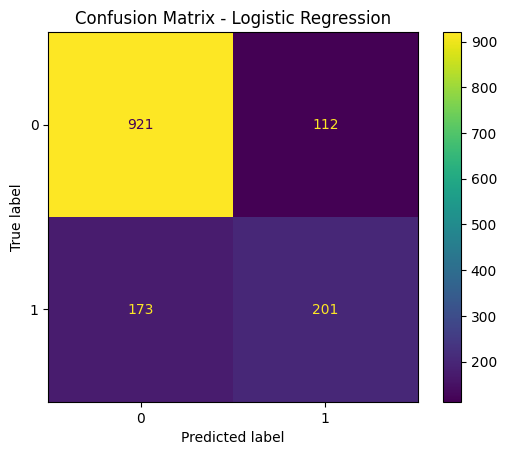

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(log_model, X_test, y_test)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [40]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred_proba)

np.float64(0.8377331483504252)

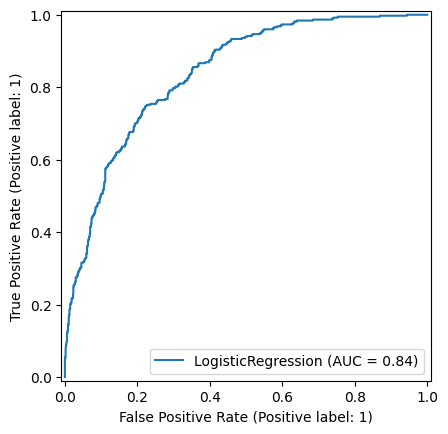

In [41]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(log_model, X_test, y_test)
plt.show()

- The Logistic Regression baseline achieves strong overall performance with a ROC-AUC of 0.84, indicating good ability to distinguish between churn and non-churn customers.

- However, recall for churned customers is 0.54, meaning the model only detects about 54% of customers who will churn.

- In a real business context, this is the most important metric: failing to identify churners means lost revenue opportunities.
Therefore, the next step is to build a more powerful model to improve churn detection.


## Advanced Model (Random Forest)

Tree-based models capture nonlinear relationships and interactions between features, often improving churn prediction performance.

## Train Random Forest

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, n_estimators=300, random_state=42)

## Predictions

In [43]:
y_pred_rf = rf_model.predict(X_test)
y_pred_rf_proba = rf_model.predict_proba(X_test)[:,1]

## Evaluate Random Forest

In [44]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf_proba))

Accuracy: 0.7882018479033405

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8364053092855552


Surprisingly, Logistic Regression slightly outperforms Random Forest.
This suggests that churn behavior in this dataset is largely linear and explainable, rather than highly complex or nonlinear.
Because Logistic Regression performs best and is highly interpretable, it will be used as the final model.

## Feature Importance

In [45]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})

feature_importance['abs_coef'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values('abs_coef', ascending=False)

feature_importance.head(15)

,Feature,Coefficient,abs_coef
28,Contract_Two year,-1.589532,1.589532
13,InternetService_Fiber optic,1.388878,1.388878
9,avg_monthly_spend,-0.998671,0.998671
4,tenure,-0.967543,0.967543
27,Contract_One year,-0.817934,0.817934
16,OnlineSecurity_Yes,-0.497197,0.497197
10,num_services,0.470098,0.470098
8,TotalCharges,0.468751,0.468751
22,TechSupport_Yes,-0.442244,0.442244
5,PhoneService,-0.370751,0.370751


### Interpretation of Top Drivers

The logistic regression coefficients reveal the most influential factors affecting churn probability.

**Strong churn reducers (negative impact on churn probability)**
Customers are significantly less likely to churn when they:

- Have two-year or one-year contracts
- Have longer tenure with the company
- Use Online Security and Tech Support services
- Show higher average monthly spend (indicating stronger engagement)
- Strong churn drivers (positive impact on churn probability)

Customers are more likely to churn when they:
- Use Fiber Optic internet service
- Pay via Electronic Check
- Subscribe to a higher number of individual services
- Accumulate higher total charges over time

These results align with the exploratory data analysis and highlight key opportunities for targeted retention strategies.

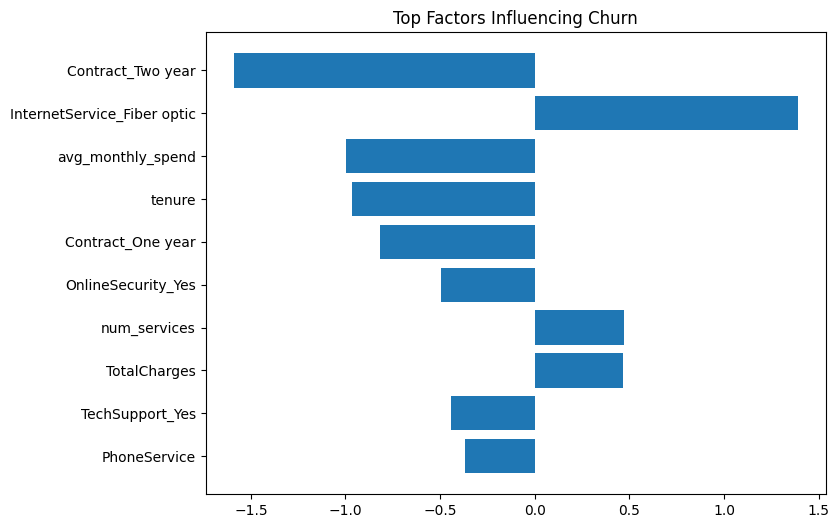

In [46]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))
plt.barh(top_features['Feature'], top_features['Coefficient'])
plt.title("Top Factors Influencing Churn")
plt.gca().invert_yaxis()
plt.show()

### How This Model Would Be Deployed in Production
This project demonstrates the complete analytics lifecycle. In a real organization, the churn prediction model would be integrated into a production data pipeline to continuously support retention initiatives and decision-making.

1. Automated Data Pipeline
Customer data would be regularly extracted from internal systems such as CRM platforms, billing databases, and product usage logs. A scheduled pipeline would apply the same preprocessing and feature engineering steps developed in this notebook to ensure consistency between training and production environments.

Typical tools:
- SQL, BigQuery, or Snowflake for data storage and querying
- Airflow or Prefect for orchestration and scheduling
- Python pipelines for preprocessing and feature engineering

2. Batch Churn Scoring
The trained model would generate churn probability scores for all active customers on a recurring schedule (for example, weekly). The output would include a probability score representing each customer’s likelihood of churn.

Customers would then be segmented into risk tiers:

- High risk: probability greater than 0.70
- Medium risk: probability between 0.40 and 0.70
- Low risk: probability below 0.40

These risk segments enable targeted and cost-effective retention strategies.

3. Integration with Business Operations
Churn predictions would be integrated into tools used by cross-functional teams.

Marketing and CRM:

- Trigger targeted retention campaigns
- Offer personalized promotions and incentives

Customer Success:

- Prioritize outreach to high-risk customers
- Provide contract upgrades or service bundles

Product Teams:

- Monitor churn trends across services and customer segments
- Identify product and service areas requiring improvement

4. Model Monitoring and Retraining
Customer behavior evolves over time, which can reduce model performance. A monitoring process would track model effectiveness and data quality on a regular basis.

Key metrics to monitor:

- ROC-AUC score
- Recall for the churn class
- Data drift in important features

The model would be retrained periodically, for example every quarter, to maintain performance and relevance.

5. Expected Business Impact
Deploying a churn prediction model enables proactive retention rather than reactive response to customer loss.

- Retaining customers is significantly more cost-effective than acquiring new ones
- Early identification of high-risk customers enables targeted interventions
- Data-driven retention strategies improve long-term customer lifetime value

### Limitations

While the model performs well, several limitations should be acknowledged:

- The dataset is relatively small (~7,000 customers)
- Class imbalance affects churn recall
- No temporal validation was performed
- The dataset is a static snapshot rather than time-series behavioral data

Future work could include advanced models (XGBoost), hyperparameter tuning, and class imbalance handling techniques such as SMOTE.

### Conclusion
This project demonstrates how data science can progress from exploration and modeling to real-world deployment, delivering actionable insights that directly support business strategy and customer retention.